In [1]:
from fastai.vision.all import *
import os
import pandas as pd
import numpy as np



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
print(os.listdir("../input"))



['test.zip', 'description.md', 'train', 'sample_submission.csv.zip', 'test', 'train.zip', 'plant-seedlings-classification', 'sample_submission.csv']


In [3]:
# Use the provided folder structure (Kaggle dataset root)
# NOTE: In this environment the competition data is under ../input/plant-seedlings-classification/
base_path = Path("../input/plant-seedlings-classification")
train_dir = base_path / "train"
test_dir = base_path / "test"
sample_sub_path = base_path / "sample_submission.csv"

print("train_dir exists:", train_dir.exists(), train_dir)
print("test_dir exists :", test_dir.exists(), test_dir)
print("sample_submission exists:", sample_sub_path.exists(), sample_sub_path)



train_dir exists: True ../input/plant-seedlings-classification/train
test_dir exists : True ../input/plant-seedlings-classification/test
sample_submission exists: True ../input/plant-seedlings-classification/sample_submission.csv


In [4]:
print(os.listdir(train_dir)[:10])
print(os.listdir(test_dir)[:10])



['Common wheat', 'Common Chickweed', 'Cleavers', 'Sugar beet', 'Fat Hen', 'Black-grass', 'Small-flowered Cranesbill', 'Loose Silky-bent', 'Shepherds Purse', 'Scentless Mayweed']
['5db43df54.png', '09d34fe5b.png', '87d1a75df.png', 'fe1092cd5.png', 'b41816608.png', 'a562c2b14.png', '79eb0958f.png', 'da007048a.png', '73600b4ed.png', '687fdd0f0.png']


['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']


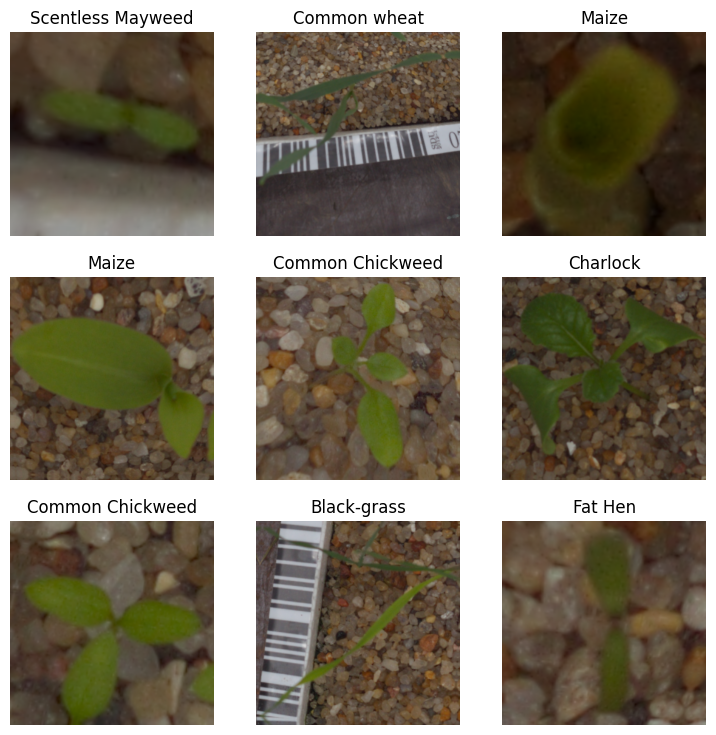

In [5]:
# fastai v2 data pipeline: keep core approach (folder-based labels, ImageNet normalization, augmentations)
# Using a fixed seed for reproducibility/stability
set_seed(42, reproducible=True)

item_tfms = Resize(336)
batch_tfms = [*aug_transforms(), Normalize.from_stats(*imagenet_stats)]

dls = ImageDataLoaders.from_folder(
    train_dir,
    valid_pct=0.2,
    seed=42,
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
    bs=16,
    num_workers=0,
)

print(dls.vocab)
dls.show_batch(max_n=9)



In [6]:
# fastai v2 learner: preserve core model choice (resnet18) and metric (accuracy)
learn = vision_learner(dls, resnet18, metrics=accuracy, model_dir=Path("/tmp/models"))



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


In [7]:
# Preserve training approach: one-cycle for 1 epoch
learn.fit_one_cycle(1)



epoch,train_loss,valid_loss,accuracy,time
0,1.595172,0.894467,0.703431,00:55


In [8]:
# Get predictions on the test set in a stable order by using sample_submission file ordering
sub_df = pd.read_csv(sample_sub_path)
test_files = sub_df["file"].tolist()
test_paths = [test_dir / f for f in test_files]

# Ensure all files exist (sanity check)
missing = [p.name for p in test_paths if not p.exists()]
if len(missing) > 0:
    raise FileNotFoundError(f"Missing {len(missing)} test images, e.g. {missing[:5]}")

test_dl = dls.test_dl(test_paths, with_labels=False)

preds, _ = learn.get_preds(dl=test_dl)
pred_idxs = preds.argmax(dim=1).cpu().numpy()

predicted_classes = [dls.vocab[i] for i in pred_idxs]
predicted_classes[:10]



['Shepherds Purse',
 'Fat Hen',
 'Fat Hen',
 'Small-flowered Cranesbill',
 'Cleavers',
 'Maize',
 'Fat Hen',
 'Scentless Mayweed',
 'Scentless Mayweed',
 'Sugar beet']

In [9]:
# Write submission with required columns and correct row order
submission = pd.DataFrame({"file": test_files, "species": predicted_classes})
submission.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", submission.shape)



Wrote submission.csv with shape: (666, 2)


In [10]:
submission.head(10)

,file,species
0,f900b7684.png,Shepherds Purse
1,9a8531ba0.png,Fat Hen
2,aac309dc5.png,Fat Hen
3,801c3e668.png,Small-flowered Cranesbill
4,be41914d8.png,Cleavers
5,5a7d10c3d.png,Maize
6,bfb59c16f.png,Fat Hen
7,a9e03b3a1.png,Scentless Mayweed
8,fd0ca2322.png,Scentless Mayweed
9,cfb3565b9.png,Sugar beet
